# 线性回归的从零开始实现

---

## 练习3.2.1

如果我们将权重初始化为零，会发生什么。算法仍然有效吗？

### &emsp;解答

&emsp;&emsp;**对线性回归而言，权重初始化为零算法仍然有效**，原因如下：

&emsp;&emsp;如果将权重初始化为零，那么每个神经元的输出都是相同的，这意味着每个神经元学习到的参数也是相同的。因此，每个神经元都会更新相同的参数，最终导致所有神经元学习到相同的特征。因此，权重初始化为零会使算法失效。这样就失去了神经网络的优势，即可以学习到不同特征的能力。

&emsp;&emsp;逻辑回归和神经网络有不同的权重初始化方法。对于逻辑回归，可以将权重初始化为零，因为这是一个线性模型，梯度下降算法仍然可以更新它们。然而，对于神经网络来说，将权重初始化为零可能会导致对称性问题，并阻止隐藏单元学习不同的特征。因此，最好使用随机或其他方法来初始化神经网络的权重。

---

## 练习3.2.2

假设试图为电压和电流的关系建立一个模型。自动微分可以用来学习模型的参数吗?

### &emsp;解答

&emsp;&emsp;根据电压（$U$）与电流（$I$）的关系，可建立线性模型：

$$U = w\, I + b$$

&emsp;&emsp;自动微分（Automatic Differentiation，简称AD）是一种对计算机程序进行高效准确求导的技术。它是介于符号微分和数值微分之间的一种方法，可以计算可导函数在某点处的导数值的计算，是反向传播算法的一般化。

&emsp;&emsp;自动微分要解决的核心问题是计算复杂函数，通常是多层复合函数在某一点处的导数、梯度以及Hessian矩阵值
torch中的backward就是自动微分。backward()函数会自动计算所有需要求导的变量的梯度，并将结果存储在相应变量的grad属性中。

&emsp;&emsp;根据书中对自动微分的描述：

> &emsp;&emsp;深度学习框架通过自动计算导数，即自动微分（automatic differentiation）来加快求导。 实际中，根据设计好的模型，系统会构建一个计算图（computational graph）， 来跟踪计算是哪些数据通过哪些操作组合起来产生输出。 自动微分使系统能够随后反向传播梯度。 这里，反向传播（backpropagate）意味着跟踪整个计算图，填充关于每个参数的偏导数。

&emsp;&emsp;用代码验证电阻为$30 \Omega$的电流与电压的计算公式：

In [25]:
import os
os.environ["TILE_FWK_DEVICE_ID"] = "0"

import torch
import pypto

首先生成数据。

In [26]:
x = torch.randn(100, 1, device='npu:0')
y = 30 * x

定义线性回归：前向 / 反向 PyPTO 算子。

In [27]:
@pypto.frontend.jit
def linreg_forward_kernel(
    X: pypto.Tensor([], pypto.DT_FP32),
    w: pypto.Tensor([], pypto.DT_FP32),
    b: pypto.Tensor([], pypto.DT_FP32),
    out: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_cube_tile_shapes([32, 32], [64, 64], [64, 64])
    pypto.set_vec_tile_shapes(*([8] * len(out.shape)))
    out[:] = pypto.matmul(X, w, pypto.DT_FP32) + b


@pypto.frontend.jit()
def linreg_backward_kernel(
    grad_out: pypto.Tensor([], pypto.DT_FP32),
    X: pypto.Tensor([], pypto.DT_FP32),
    w: pypto.Tensor([], pypto.DT_FP32),
    grad_X: pypto.Tensor([], pypto.DT_FP32),
    grad_w: pypto.Tensor([], pypto.DT_FP32),
    grad_b: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_cube_tile_shapes([32, 32], [64, 64], [64, 64])
    grad_X[:] = pypto.matmul(grad_out, w, pypto.DT_FP32, b_trans=True)
    grad_w[:] = pypto.matmul(X, grad_out, pypto.DT_FP32, a_trans=True)
    pypto.set_vec_tile_shapes(*([8] * len(grad_out.shape)))
    grad_b[:] = pypto.sum(grad_out, dim=0, keepdim=False)


class PyPTOLinRegFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, X, w, b):
        out = torch.empty((X.shape[0], 1), dtype=X.dtype, device=X.device)
        linreg_forward_kernel(X, w, b, out)
        ctx.save_for_backward(X, w)
        return out

    @staticmethod
    def backward(ctx, grad_out):
        X, w = ctx.saved_tensors
        grad_out_c = grad_out.contiguous() if not grad_out.is_contiguous() else grad_out
        grad_X = torch.empty_like(X)
        grad_w = torch.empty_like(w)
        grad_b = torch.empty((1,), dtype=w.dtype, device=w.device)
        linreg_backward_kernel(grad_out_c, X, w, grad_X, grad_w, grad_b)
        return grad_X, grad_w, grad_b

定义 MSE 损失：前向 / 反向 PyPTO 算子。

In [28]:
@pypto.frontend.jit()
def mse_loss_forward_kernel(
    y_hat: pypto.Tensor([], pypto.DT_FP32),
    y: pypto.Tensor([], pypto.DT_FP32),
    out: pypto.Tensor([], pypto.DT_FP32),
    n: float,
):
    pypto.set_vec_tile_shapes(*([8] * len(y_hat.shape)))
    diff = y_hat - y
    sq = diff ** 2
    reduced = pypto.sum(sq, dim=0)
    reduced = pypto.sum(reduced, dim=0)
    out[:] = reduced / n


@pypto.frontend.jit()
def mse_loss_backward_kernel(
    grad_out: pypto.Tensor([], pypto.DT_FP32),
    y_hat: pypto.Tensor([], pypto.DT_FP32),
    y: pypto.Tensor([], pypto.DT_FP32),
    grad_y_hat: pypto.Tensor([], pypto.DT_FP32),
    grad_y: pypto.Tensor([], pypto.DT_FP32),
    n: float,
):
    pypto.set_vec_tile_shapes(*([8] * len(y_hat.shape)))
    diff = y_hat - y
    factor = 2.0 * grad_out / n
    grad_y_hat[:] = factor * diff
    grad_y[:] = 0.0 - factor * diff


class PyPTOMSELossFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, y_hat, y):
        n = y_hat.numel()
        out = torch.empty((1,), dtype=y_hat.dtype, device=y_hat.device)
        mse_loss_forward_kernel(y_hat, y, out, float(n))
        ctx.save_for_backward(y_hat, y)
        ctx.n = n
        return out.view(())

    @staticmethod
    def backward(ctx, grad_out):
        y_hat, y = ctx.saved_tensors
        grad_out_c = grad_out.contiguous() if not grad_out.is_contiguous() else grad_out
        grad_y_hat = torch.empty_like(y_hat)
        grad_y = torch.empty_like(y)
        mse_loss_backward_kernel(grad_out_c, y_hat, y, grad_y_hat, grad_y, float(ctx.n))
        return grad_y_hat, grad_y

定义参数与训练组件。

In [29]:
w = torch.zeros(1, 1, requires_grad=True, device='npu:0')
b = torch.zeros(1, requires_grad=True, device='npu:0')
net = lambda X, w, b: PyPTOLinRegFunction.apply(X, w, b)
loss_fn = lambda y_hat, y: PyPTOMSELossFunction.apply(y_hat, y)

然后我们开始训练。

In [30]:
for epoch in range(50):
    # 前向传播
    y_pred = net(x, w, b)

    # 计算损失
    l = loss_fn(y_pred, y)

    # 反向传播
    l.backward()
    with torch.no_grad():
        w -= 0.1 * w.grad
        b -= 0.1 * b.grad
        w.grad.zero_()
        b.grad.zero_()

输出训练结果。

In [31]:
print(w)
print(b)

tensor([[29.9988]], device='npu:0', requires_grad=True)
tensor([0.0015], device='npu:0', requires_grad=True)


---

## 练习3.2.3

能基于[普朗克定律](https://en.wikipedia.org/wiki/Planck%27s_law)使用光谱能量密度来确定物体的温度吗？

### &emsp;解答

&emsp;&emsp;根据维基百科：
> &emsp;&emsp;在物理学中，普朗克黑体辐射定律（也简称普朗克定律或黑体辐射定律）是指在任意温度$\displaystyle T$下，从一个黑体中发射出的电磁辐射的辐射率与频率之间的关系，在这里，辐射率是频率$\nu$的函数：
> $$
I_{\nu }(\nu ,T)={\frac {2h\nu ^{3}}{c^{2}}}{\frac {1}{e^{\frac {h\nu }{kT}}-1}}
$$
其中，$I_{\nu}$是辐射率，$\nu$是频率，$T$是黑体的温度，$h$是普朗克常数，$c$是光速，$k$是波兹曼常数。
> 
> 根据电磁波波长和频率的关系为：
> $$
\lambda = \frac{c}{\nu}
$$
> 普朗克定律有时写做能量密度频谱的形式：
> $$
u_{ \nu }(\nu ,T) 
= \frac{4 \pi}{c} I_{\nu }(\nu ,T) 
= \frac {8 \pi h \nu^{3}}{c^3} \frac {1}{e^{\frac {h\nu }{kT}} - 1}
$$

&emsp;&emsp;根据上述公式，可以得到物体的温度计算公式：
$$
T = \frac{h \nu}{K \ln \left( 1 + \displaystyle \frac{8 \pi h \nu^3}{c^3 u_{\nu}} \right)}
$$
&emsp;&emsp;通过测量物体发出的辐射能量密度，并使用普朗克定律，可以确定物体的温度。

---

## 练习3.2.4

计算二阶导数时可能会遇到什么问题？这些问题可以如何解决？

### &emsp;解答

&emsp;&emsp;计算二阶导数时可能会遇到如下问题：

1. 数值不稳定性问题：该问题可以通过使用更高精度的数据类型（例如双精度浮点数）或通过使用数值稳定性技巧（例如中心差分）来解决。  
中心差分是一种常用的数值稳定性技巧，它可以用于计算函数在某个点处的导数。具体来说，中心差分可以通过以下公式计算：

$$f'(x) \approx \frac{f(x+h)-f(x-h)}{2h}$$

&emsp;&emsp;其中 $h$ 是一个很小的正数，通常取 $10^{-6}$ 或更小。

2. 一阶导数的计算图保存问题：计算二阶导数，需要将一阶导数的计算图保存起来，使用`create_graph`和`retain_graph`参数。

&emsp;&emsp;以下面函数举例：

- 原函数：$ y = x^3$
- 一阶导函数：$y = 3 x^2$
- 二阶导函数：$y = 6 x$

&emsp;&emsp;在 PyPTO 中，框架本身并不内置自动微分，因此对各阶导数需要**手动推导解析公式**并写成前向 kernel。这种“手导”方式天然地绕过了 `create_graph`/`retain_graph` 与计算图保存的复杂性，也避免了有限差分带来的数值不稳定——所有导数都由 PyPTO 的基本前向算子解析地组合得到。代价是：当函数更复杂时，手动推导本身容易出错且难以维护。本练习以 PyTorch 的 `torch.autograd.grad` 作为 golden 验证 PyPTO kernel 的正确性。

&emsp;&emsp;首先，我们用 PyPTO 定义算子。

In [32]:
import torch
import pypto

x = torch.randn(2, device='npu:0')


@pypto.frontend.jit()
def cube_forward_kernel(
    x: pypto.Tensor([], pypto.DT_FP32),
    out: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(*([8] * len(out.shape)))
    out[:] = x ** 3


@pypto.frontend.jit()
def cube_first_derivative_kernel(
    x: pypto.Tensor([], pypto.DT_FP32),
    out: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(*([8] * len(out.shape)))
    out[:] = 3.0 * x * x


@pypto.frontend.jit()
def cube_second_derivative_kernel(
    x: pypto.Tensor([], pypto.DT_FP32),
    out: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(*([8] * len(out.shape)))
    out[:] = 6.0 * x

先计算一阶前向。

In [33]:
y = torch.empty_like(x)
cube_forward_kernel(x, y)

随后，分别用 PyPTO 和 PyTorch 计算一、二阶导数。

In [34]:
# 一阶 / 二阶导数：调用手导公式的 PyPTO kernel
dy = torch.empty_like(x)
dy2 = torch.empty_like(x)
cube_first_derivative_kernel(x, dy)
cube_second_derivative_kernel(x, dy2)

# 同步用 PyTorch autograd 作为 golden 验证
x_g = x.detach().clone().requires_grad_(True)
y_g = x_g ** 3
dy_golden = torch.autograd.grad(
    y_g, x_g, grad_outputs=torch.ones_like(x_g),
    retain_graph=True, create_graph=True,
)[0]
dy2_golden = torch.autograd.grad(
    dy_golden, x_g, grad_outputs=torch.ones_like(x_g),
)[0]

最后验证结果。

In [35]:
print("dy              =", dy)
print("3 * x ** 2      =", 3 * x ** 2)
print("dy_golden       =", dy_golden.detach())
print("dy == 3*x**2    :", torch.allclose(dy, 3 * x ** 2))
print("dy == dy_golden :", torch.allclose(dy, dy_golden.detach()))

dy              = tensor([0.2195, 0.0658], device='npu:0')
3 * x ** 2      = tensor([0.2195, 0.0658], device='npu:0')
dy_golden       = tensor([0.2195, 0.0658], device='npu:0')
dy == 3*x**2    : True
dy == dy_golden : True


In [36]:
print("dy2              =", dy2)
print("6 * x            =", 6 * x)
print("dy2_golden       =", dy2_golden.detach())
print("dy2 == 6*x       :", torch.allclose(dy2, 6 * x))
print("dy2 == dy2_golden:", torch.allclose(dy2, dy2_golden.detach()))

dy2              = tensor([1.6231, 0.8888], device='npu:0')
6 * x            = tensor([1.6231, 0.8888], device='npu:0')
dy2_golden       = tensor([1.6231, 0.8888], device='npu:0')
dy2 == 6*x       : True
dy2 == dy2_golden: True


---

## 练习3.2.5

为什么在`squared_loss`函数中需要使用`reshape`函数？

### &emsp;解答

&emsp;&emsp;原书中 3.2.5 节的 `squared_loss` 代码为：

```python
def squared_loss(y_hat, y):
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2
```

&emsp;&emsp;改写的 `squared_loss_forward_kernel` 内没有使用 `reshape`，但在调用 kernel 前存在：

```python
y_reshaped = y.reshape(y_hat.shape)
out = torch.empty_like(y_hat)
squared_loss_forward_kernel(y_hat, y_reshaped, out)
```

&emsp;&emsp;这里使用`reshape`函数是为了保证`y`和`y_hat`形状相同，避免触发广播机制导致错误的结果。

---

## 练习3.2.6

尝试使用不同的学习率，观察损失函数值下降的快慢。

### &emsp;解答

&emsp;&emsp;与我们在3.3节中介绍的方法类似，下面使用 PyPTO 算子构造线性回归前向与平方损失前向 kernel，借助 PyTorch 自动微分完成反向，再用 PyTorch 的 `SGD` 在不同学习率下观察训练过程。

In [ ]:
%matplotlib inline
import os
os.environ["TILE_FWK_DEVICE_ID"] = "0"

import random
import torch
import pypto
import numpy as np
import matplotlib.pyplot as plt

线性回归：前向 / 反向 PyPTO 算子。

In [38]:
@pypto.frontend.jit
def linreg_forward_kernel(
    X: pypto.Tensor([], pypto.DT_FP32),
    w: pypto.Tensor([], pypto.DT_FP32),
    b: pypto.Tensor([], pypto.DT_FP32),
    out: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_cube_tile_shapes([32, 32], [64, 64], [64, 64])
    pypto.set_vec_tile_shapes(*([8] * len(out.shape)))
    out[:] = pypto.matmul(X, w, pypto.DT_FP32) + b


@pypto.frontend.jit()
def linreg_backward_kernel(
    grad_out: pypto.Tensor([], pypto.DT_FP32),
    X: pypto.Tensor([], pypto.DT_FP32),
    w: pypto.Tensor([], pypto.DT_FP32),
    grad_X: pypto.Tensor([], pypto.DT_FP32),
    grad_w: pypto.Tensor([], pypto.DT_FP32),
    grad_b: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_cube_tile_shapes([32, 32], [64, 64], [64, 64])
    grad_X[:] = pypto.matmul(grad_out, w, pypto.DT_FP32, b_trans=True)
    grad_w[:] = pypto.matmul(X, grad_out, pypto.DT_FP32, a_trans=True)

    pypto.set_vec_tile_shapes(*([8] * len(grad_out.shape)))
    grad_b[:] = pypto.sum(grad_out, dim=0, keepdim=False)


class PyPTOLinRegFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, X, w, b):
        out = torch.empty((X.shape[0], 1), dtype=X.dtype, device=X.device)
        linreg_forward_kernel(X, w, b, out)
        ctx.save_for_backward(X, w)
        return out

    @staticmethod
    def backward(ctx, grad_out):
        X, w = ctx.saved_tensors
        grad_out_c = grad_out.contiguous() if not grad_out.is_contiguous() else grad_out
        grad_X = torch.empty_like(X)
        grad_w = torch.empty_like(w)
        grad_b = torch.empty((1,), dtype=w.dtype, device=w.device)
        linreg_backward_kernel(grad_out_c, X, w, grad_X, grad_w, grad_b)
        return grad_X, grad_w, grad_b

线性回归：前向 / 反向 PyPTO 算子。

In [39]:
@pypto.frontend.jit()
def squared_loss_forward_kernel(
    y_hat: pypto.Tensor([], pypto.DT_FP32),
    y: pypto.Tensor([], pypto.DT_FP32),
    out: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(*([8] * len(y_hat.shape)))
    diff = y_hat - y
    out[:] = diff ** 2 / 2


@pypto.frontend.jit()
def squared_loss_backward_kernel(
    grad_out: pypto.Tensor([], pypto.DT_FP32),
    y_hat: pypto.Tensor([], pypto.DT_FP32),
    y: pypto.Tensor([], pypto.DT_FP32),
    grad_y_hat: pypto.Tensor([], pypto.DT_FP32),
    grad_y: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(*([8] * len(y_hat.shape)))
    diff = y_hat - y
    grad_y_hat[:] = grad_out * diff
    grad_y[:] = grad_out * (0.0 - diff)


class PyPTOSquaredLossFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, y_hat, y):
        y_reshaped = y.reshape(y_hat.shape)
        out = torch.empty_like(y_hat)
        squared_loss_forward_kernel(y_hat, y_reshaped, out)
        ctx.save_for_backward(y_hat, y_reshaped)
        return out

    @staticmethod
    def backward(ctx, grad_out):
        y_hat, y = ctx.saved_tensors
        grad_out_c = grad_out.contiguous() if not grad_out.is_contiguous() else grad_out
        grad_y_hat = torch.empty_like(y_hat)
        grad_y = torch.empty_like(y)
        squared_loss_backward_kernel(grad_out_c, y_hat, y, grad_y_hat, grad_y)
        return grad_y_hat, None

接下来定义数据、模型、损失函数以及优化器。

In [40]:
def synthetic_data(w, b, num_examples):
    """生成 y = X w + b + 噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)), device='npu:0')
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape, device='npu:0')
    return X, y.reshape((-1, 1))

def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i: min(i + batch_size, num_examples)], device='npu:0')
        yield features[batch_indices], labels[batch_indices]

true_w = torch.tensor([2, -3.4], device='npu:0')
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

w0 = torch.normal(0, 0.01, size=(2, 1), requires_grad=True, device='npu:0')
b0 = torch.zeros(1, requires_grad=True, device='npu:0')

net = lambda X, w, b: PyPTOLinRegFunction.apply(X, w, b)
loss = lambda y_hat, y: PyPTOSquaredLossFunction.apply(y_hat, y)

然后开始训练。

In [41]:
lrs = [0.5, 0.3, 0.1, 0.07]
num_epochs = 10
batch_size = 10

all_lrs = []
for lr in lrs:
    w = w0.clone().detach().requires_grad_(True)
    b = b0.clone().detach().requires_grad_(True)
    train_lrs = []
    for epoch in range(num_epochs):
        for X, y in data_iter(batch_size, features, labels):
            l = loss(net(X, w, b), y)
            l.sum().backward()
            with torch.no_grad():
                w -= lr * w.grad / batch_size
                b -= lr * b.grad / batch_size
                w.grad.zero_()
                b.grad.zero_()
        with torch.no_grad():
            train_l = loss(net(features, w, b), labels)
            train_lrs.append(float(train_l.mean()))
    all_lrs.append(train_lrs)

最后展示学习率与训练效果的关系。

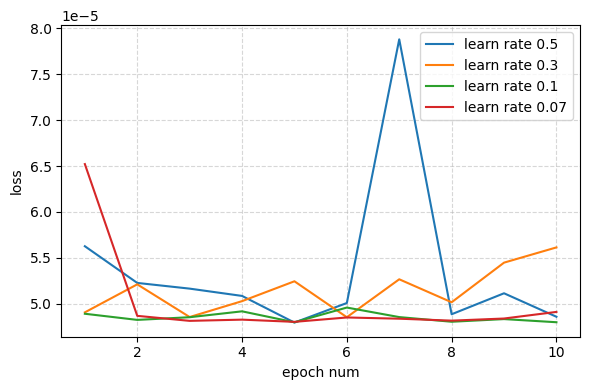

In [42]:
epochs = np.arange(1, num_epochs + 1)
plt.figure(figsize=(6, 4))
for i, lr in enumerate(lrs):
    plt.plot(epochs, all_lrs[i], label=f'learn rate {lr}')
plt.xlabel('epoch num')
plt.ylabel('loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


&emsp;&emsp;根据上述实验结果，可得到如下结论：

1. **学习率过大**：前期损失下降快，但后期损失在最优解附近震荡，难以稳定收敛。
2. **学习率过小**：损失下降非常缓慢，甚至在给定 epoch 内无法下降到较低水平。
3. **合适的学习率**（如 $0.1$ 左右）：能够较快地收敛到接近 $0$ 的损失值。

---

## 练习3.2.7

如果样本个数不能被批量大小整除，`data_iter`函数的行为会有什么变化？

### &emsp;解答

&emsp;&emsp;如果样本个数不能被批量大小整除，那么最后一个小批量的样本数会少于 `batch_size`。在当前 `data_iter` 实现中，这部分样本不会被舍弃，而是作为一个更小的 batch 正常返回。例如总样本数为 1000、`batch_size=3` 时，最后一个 batch 只包含 1 个样本。